# 00 Capture and Preprocess

**Purpose:** Prepare a clean photo set for reconstruction.

## Inputs
- Folder of raw images captured around the subject
- Optional masks or segmentation outputs

## Outputs
- Curated image set
- Image quality report
- Optional resized / undistorted / masked images

## What needs to be done
- [ ] Load image paths and inspect image count
- [ ] Compute blur / sharpness metrics and flag poor images
- [ ] Check resolution consistency and orientation
- [ ] Optionally resize while preserving reconstruction quality
- [ ] Optionally mask background if needed
- [ ] Save a cleaned image subset for downstream steps

## Notes
- Keep code in this notebook focused on experimentation and visualization.
- As soon as a block becomes reusable, move it into `src/`.
- Save intermediate artifacts so later notebooks do not need to recompute everything.

## Imports and Paths

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import pandas as pd

: 

## Load and Inspect Images

Found 100 images.


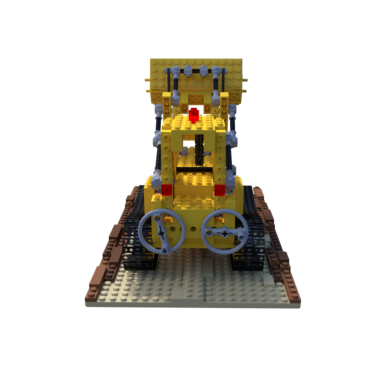

In [9]:
image_dir = Path("../aloi_data/nerf_synthetic/lego/train")
extensions = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
image_files = []
for ext in extensions:
    image_files.extend(image_dir.glob(ext))

print(f"Found {len(image_files)} images.")

img = Image.open(image_files[0])
plt.imshow(img)
plt.axis("off")
plt.show()

## Blur / Quality Filtering

In [ ]:
def laplacian_variance(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    return cv2.Laplacian(img, cv2.CV_64F).var()

rows = []
for path in image_files:
    score = laplacian_variance(path)
    rows.append(({"image": path.name, "sharpness": score}))

df = pd.DataFrame(rows).sort_values("sharpness")
df.head(10)

## Optional Background Masking

## Resize / Normalize Export

## Save Preprocessed Dataset